In [1]:
# ==================================================
# IMPORT LIBRARY
# ==================================================

import os
import json
import shutil
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from PIL import ImageFile

ImageFile.LOAD_TRUNCATED_IMAGES = True

import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    GlobalAveragePooling2D
)
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

print("✓ Import berhasil")

✓ Import berhasil


In [2]:
# ==================================================
# DOWNLOAD DATASET
# ==================================================

from google.colab import files

files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets list -s insect

!kaggle datasets download -d baxtiyorbotiraliyev/insects

!unzip insects.zip -d dataset

print("✓ Dataset berhasil diunduh")

Output streaming akan dipotong hingga 5000 baris terakhir.
  inflating: dataset/dataset/val/leaf beetle/834maize_valid_leaf beetle.JPG  
  inflating: dataset/dataset/val/leaf beetle/836maize_valid_leaf beetle.JPG  
  inflating: dataset/dataset/val/leaf beetle/838maize_valid_leaf beetle.JPG  
  inflating: dataset/dataset/val/leaf beetle/841maize_train_leaf beetle.JPG  
  inflating: dataset/dataset/val/leaf beetle/845maize_train_leaf beetle.JPG  
  inflating: dataset/dataset/val/leaf beetle/856maize_valid_leaf beetle.JPG  
  inflating: dataset/dataset/val/leaf beetle/862maize_valid_leaf beetle.JPG  
  inflating: dataset/dataset/val/leaf beetle/863maize_train_leaf beetle.JPG  
  inflating: dataset/dataset/val/leaf beetle/883maize_train_leaf beetle.JPG  
  inflating: dataset/dataset/val/leaf beetle/892maize_valid_leaf beetle.JPG  
  inflating: dataset/dataset/val/leaf beetle/8maize_valid_leaf beetle.JPG  
  inflating: dataset/dataset/val/leaf beetle/904maize_valid_leaf beetle.JPG  
  infla

In [3]:
# ==================================================
# CEK GPU
# ==================================================

print(tf.__version__)
print(tf.config.list_physical_devices("GPU"))

2.20.0
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
# ==================================================
# DATASET ASLI
# ==================================================

DATASET_DIR = "/content/dataset/dataset"

TRAIN_ORIGINAL = os.path.join(DATASET_DIR, "train")
VAL_ORIGINAL   = os.path.join(DATASET_DIR, "val")
TEST_ORIGINAL  = os.path.join(DATASET_DIR, "test")

classes = sorted(os.listdir(TRAIN_ORIGINAL))

print("="*50)
print("INFORMASI DATASET")
print("="*50)
print("Jumlah kelas :", len(classes))

INFORMASI DATASET
Jumlah kelas : 118


In [5]:
# ==================================================
# CEK GAMBAR RUSAK
# ==================================================

from PIL import Image

def quick_check(folder):

    checked = 0
    corrupted = []

    for root, dirs, files in os.walk(folder):

        for file in files:

            path = os.path.join(root, file)

            try:

                with Image.open(path) as img:
                    img.verify()

                with Image.open(path) as img:
                    img = img.convert("RGB")
                    img.load()
                    img.resize((224,224))

            except Exception:
                corrupted.append(path)

            checked += 1

    return corrupted, checked

In [6]:
corrupted_train, checked_train = quick_check(TRAIN_ORIGINAL)
corrupted_val, checked_val = quick_check(VAL_ORIGINAL)
corrupted_test, checked_test = quick_check(TEST_ORIGINAL)

print("="*50)
print("CORRUPTED IMAGE CHECK")
print("="*50)

print(
    f"Train : {len(corrupted_train)} rusak dari {checked_train}"
)

print(
    f"Val   : {len(corrupted_val)} rusak dari {checked_val}"
)

print(
    f"Test  : {len(corrupted_test)} rusak dari {checked_test}"
)

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Corrupt EXIF data.  Expecting to read 4 bytes but only got 0. 
  warnings.warn(str(msg))


CORRUPTED IMAGE CHECK
Train : 6 rusak dari 90115
Val   : 2 rusak dari 11215
Test  : 2 rusak dari 11363


In [7]:
# ==================================================
# HAPUS GAMBAR RUSAK
# ==================================================

deleted = 0

for f in corrupted_train:
    os.remove(f)
    deleted += 1

for f in corrupted_val:
    os.remove(f)
    deleted += 1

for f in corrupted_test:
    os.remove(f)
    deleted += 1

print("="*50)
print("FILE CORRUPT DIHAPUS")
print("="*50)
print("Total :", deleted)

FILE CORRUPT DIHAPUS
Total : 10


In [8]:
# ==================================================
# SPLIT ULANG DATASET
# ==================================================

import os
import shutil
import random
from sklearn.model_selection import train_test_split

SOURCE_DIR = "/content/dataset/dataset/train"

NEW_DATASET_DIR = "/content/dataset_clean"

TRAIN_DIR = os.path.join(NEW_DATASET_DIR, "train")
VAL_DIR = os.path.join(NEW_DATASET_DIR, "val")
TEST_DIR = os.path.join(NEW_DATASET_DIR, "test")

# Hapus dataset_clean lama jika ada
if os.path.exists(NEW_DATASET_DIR):
    shutil.rmtree(NEW_DATASET_DIR)

# Buat folder baru
os.makedirs(TRAIN_DIR)
os.makedirs(VAL_DIR)
os.makedirs(TEST_DIR)

classes = sorted(os.listdir(SOURCE_DIR))

print("="*50)
print("MEMBUAT DATASET CLEAN")
print("="*50)

for class_name in classes:

    source_class_dir = os.path.join(
        SOURCE_DIR,
        class_name
    )

    if not os.path.isdir(source_class_dir):
        continue

    images = [
        img for img in os.listdir(source_class_dir)
        if img.lower().endswith(
            (".jpg", ".jpeg", ".png")
        )
    ]

    if len(images) < 3:
        continue

    # Acak gambar
    random.shuffle(images)

    # Train 70%
    train_imgs, temp_imgs = train_test_split(
        images,
        test_size=0.30,
        random_state=42
    )

    # Val 15%
    # Test 15%
    val_imgs, test_imgs = train_test_split(
        temp_imgs,
        test_size=0.50,
        random_state=42
    )

    train_class_dir = os.path.join(
        TRAIN_DIR,
        class_name
    )

    val_class_dir = os.path.join(
        VAL_DIR,
        class_name
    )

    test_class_dir = os.path.join(
        TEST_DIR,
        class_name
    )

    os.makedirs(train_class_dir)
    os.makedirs(val_class_dir)
    os.makedirs(test_class_dir)

    # ==========================
    # Copy Train
    # ==========================

    for img in train_imgs:

        shutil.copy2(
            os.path.join(source_class_dir, img),
            os.path.join(train_class_dir, img)
        )

    # ==========================
    # Copy Val
    # ==========================

    for img in val_imgs:

        shutil.copy2(
            os.path.join(source_class_dir, img),
            os.path.join(val_class_dir, img)
        )

    # ==========================
    # Copy Test
    # ==========================

    for img in test_imgs:

        shutil.copy2(
            os.path.join(source_class_dir, img),
            os.path.join(test_class_dir, img)
        )

print("="*50)
print("SPLIT DATASET SELESAI")
print("="*50)

print("Train :", len(os.listdir(TRAIN_DIR)), "kelas")
print("Val   :", len(os.listdir(VAL_DIR)), "kelas")
print("Test  :", len(os.listdir(TEST_DIR)), "kelas")

MEMBUAT DATASET CLEAN
SPLIT DATASET SELESAI
Train : 118 kelas
Val   : 118 kelas
Test  : 118 kelas


In [9]:
sample_class = os.listdir(TRAIN_DIR)[0]

print(
    sample_class,
    len(
        os.listdir(
            os.path.join(
                TRAIN_DIR,
                sample_class
            )
        )
    )
)

small brown plant hopper 309


In [10]:
# ==================================================
# DATASET CLEAN AKTIF
# ==================================================

TRAIN_DIR = "/content/dataset_clean/train"
VAL_DIR   = "/content/dataset_clean/val"
TEST_DIR  = "/content/dataset_clean/test"

print("Dataset clean aktif")

Dataset clean aktif


In [26]:
# ==================================================
# LABEL ENCODING
# ==================================================

classes = sorted(
    os.listdir(TRAIN_DIR)
)

class_indices = {
    cls: idx
    for idx, cls in enumerate(classes)
}

with open(
    "class_names.json",
    "w"
) as f:

    json.dump(
        classes,
        f
    )

print(
    "Jumlah kelas:",
    len(classes)
)

Jumlah kelas: 118


In [27]:
# ==================================================
# AUGMENTASI
# ==================================================

IMG_SIZE = 160
BATCH_SIZE = 64

train_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    fill_mode="nearest"
)

val_test_datagen = ImageDataGenerator(
    rescale=1./255
)

print("Augmentasi siap")

Augmentasi siap


In [28]:
# ==================================================
# DATA LOADER
# ==================================================

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(160,160),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

val_generator = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(160,160),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(160,160),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

print("="*50)
print("DATA LOADER BERHASIL")
print("="*50)

print(
    "Train Samples :",
    train_generator.samples
)

print(
    "Val Samples :",
    val_generator.samples
)

print(
    "Test Samples :",
    test_generator.samples
)

Found 63024 images belonging to 118 classes.
Found 13515 images belonging to 118 classes.
Found 13570 images belonging to 118 classes.
DATA LOADER BERHASIL
Train Samples : 63024
Val Samples : 13515
Test Samples : 13570


In [29]:
# ==================================================
# BUILD MODEL
# ==================================================

NUM_CLASSES = len(classes)

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(160,160,3)
)

base_model.trainable = False

x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dropout(0.3)(x)

x = Dense(
    512,
    activation="relu"
)(x)

x = Dropout(0.3)(x)

outputs = Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

model = Model(
    inputs=base_model.input,
    outputs=outputs
)

print("="*50)
print("MODEL BERHASIL DIBUAT")
print("="*50)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MODEL BERHASIL DIBUAT


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 160, 160,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 80, 80,    │        864 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 80, 80,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 80, 80,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 80, 80,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 80, 80,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 80, 80,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 80, 80,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 80, 80,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 81, 81,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 40, 40,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 40, 40,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 40, 40,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 40, 40,    │      2,304 │ block_1_depthwis

 Total params: 2,974,390 (11.35 MB)

 Trainable params: 716,406 (2.73 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [30]:
# ==================================================
# COMPILE MODEL
# ==================================================

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("="*50)
print("MODEL BERHASIL DI-COMPILE")
print("="*50)

MODEL BERHASIL DI-COMPILE


In [31]:
# ==================================================
# CALLBACK
# ==================================================

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

print("="*50)
print("CALLBACK SIAP")
print("="*50)

CALLBACK SIAP


In [32]:
# ==================================================
# VALIDASI DATASET
# ==================================================

corrupted_train, _ = quick_check(TRAIN_DIR)
corrupted_val, _ = quick_check(VAL_DIR)
corrupted_test, _ = quick_check(TEST_DIR)

print("="*50)
print("VALIDASI SEBELUM TRAINING")
print("="*50)

print("Train :", len(corrupted_train))
print("Val   :", len(corrupted_val))
print("Test  :", len(corrupted_test))

VALIDASI SEBELUM TRAINING
Train : 0
Val   : 0
Test  : 0


In [33]:
# ==================================================
# TRAINING
# ==================================================

EPOCHS = 10

print("="*50)
print("MEMULAI TRAINING")
print("="*50)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ]
)

MEMULAI TRAINING
Epoch 1/10
985/985 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step - accuracy: 0.3657 - loss: 2.8476
Epoch 1: val_accuracy improved from None to 0.56034, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
985/985 ━━━━━━━━━━━━━━━━━━━━ 260s 245ms/step - accuracy: 0.4356 - loss: 2.3977 - val_accuracy: 0.5603 - val_loss: 1.7665 - learning_rate: 0.0010
Epoch 2/10
985/985 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - accuracy: 0.5217 - loss: 1.8667
Epoch 2: val_accuracy improved from 0.56034 to 0.59119, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
985/985 ━━━━━━━━━━━━━━━━━━━━ 235s 239ms/step - accuracy: 0.5254 - loss: 1.8555 - val_accuracy: 0.5912 - val_loss: 1.6090 - learning_rate: 0.0010
Epoch 3/10
985/985 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.5608 - loss: 1.6785
Epoch 3: val_accuracy improved from 0.59119 to 0.60074, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
985/985 ━

In [34]:
# ==================================================
# FINE TUNING
# ==================================================

print("="*50)
print("MEMULAI FINE TUNING")
print("="*50)

base_model.trainable = True

# Bekukan sebagian besar layer
for layer in base_model.layers[:-30]:
    layer.trainable = False

print(
    "Jumlah layer MobileNetV2:",
    len(base_model.layers)
)

print(
    "Fine tuning aktif"
)

MEMULAI FINE TUNING
Jumlah layer MobileNetV2: 154
Fine tuning aktif


In [35]:
# ==================================================
# RECOMPILE MODEL
# ==================================================

from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(
        learning_rate=1e-5
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model berhasil di-compile ulang")

Model berhasil di-compile ulang


In [36]:
# ==================================================
# CALLBACK FINE TUNING
# ==================================================

fine_early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

fine_reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

In [37]:
# ==================================================
# TRAINING FINE TUNING
# ==================================================

FINE_TUNE_EPOCHS = 3

history_fine = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=FINE_TUNE_EPOCHS,
    callbacks=[
        fine_early_stop,
        fine_reduce_lr,
        checkpoint
    ]
)

Epoch 1/3
985/985 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step - accuracy: 0.5076 - loss: 1.9503
Epoch 1: val_accuracy did not improve from 0.64025
985/985 ━━━━━━━━━━━━━━━━━━━━ 264s 248ms/step - accuracy: 0.5438 - loss: 1.7495 - val_accuracy: 0.6399 - val_loss: 1.4275 - learning_rate: 1.0000e-05
Epoch 2/3
985/985 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step - accuracy: 0.6032 - loss: 1.4464
Epoch 2: val_accuracy improved from 0.64025 to 0.64861, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
985/985 ━━━━━━━━━━━━━━━━━━━━ 221s 224ms/step - accuracy: 0.6129 - loss: 1.4208 - val_accuracy: 0.6486 - val_loss: 1.3941 - learning_rate: 1.0000e-05
Epoch 3/3
985/985 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - accuracy: 0.6359 - loss: 1.3216
Epoch 3: val_accuracy improved from 0.64861 to 0.65461, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
985/985 ━━━━━━━━━━━━━━━━━━━━ 216s 219ms/step - accuracy: 0.6385 - loss: 1.3075 - val_accuracy: 0.6546 - val_

In [38]:
# ==================================================
# LOAD BEST MODEL
# ==================================================

model.load_weights(
    "best_model.keras"
)

print("Best model berhasil dimuat")

Best model berhasil dimuat


In [39]:
# ==================================================
# TEST EVALUATION
# ==================================================

test_loss, test_acc = model.evaluate(
    test_generator,
    verbose=1
)

print("="*50)
print("HASIL TEST")
print("="*50)

print(
    "Test Loss :",
    round(test_loss,4)
)

print(
    "Test Accuracy :",
    round(test_acc*100,2),
    "%"
)

213/213 ━━━━━━━━━━━━━━━━━━━━ 46s 215ms/step - accuracy: 0.6566 - loss: 1.3587
HASIL TEST
Test Loss : 1.3587
Test Accuracy : 65.66 %


In [40]:
# ==================================================
# PREDIKSI TEST SET
# ==================================================

test_generator.reset()

predictions = model.predict(
    test_generator,
    verbose=1
)

y_pred_classes = np.argmax(
    predictions,
    axis=1
)

y_true = test_generator.classes

213/213 ━━━━━━━━━━━━━━━━━━━━ 45s 188ms/step


In [41]:
# ==================================================
# CLASSIFICATION REPORT
# ==================================================

print(
    classification_report(
        y_true,
        y_pred_classes,
        target_names=classes
    )
)

                                 precision    recall  f1-score   support

                  adristyrannus       0.64      0.47      0.55        38
       aleurocanthus spiniferus       0.66      0.84      0.74        83
              alfalfa plant bug       0.38      0.19      0.25        79
           alfalfa seed chalcid       0.57      0.17      0.27        23
                 alfalfa weevil       0.50      0.21      0.29        63
                    ampelophaga       0.63      0.63      0.63        92
                            ant       0.77      0.84      0.80       231
                         aphids       0.53      0.75      0.62       744
               apolygus lucorum       0.32      0.22      0.26        46
                       armyworm       0.40      0.49      0.44       424
             asiatic rice borer       0.37      0.46      0.41       127
           bactrocera tsuneonis       0.44      0.19      0.27        21
                            bee       0.87      0.

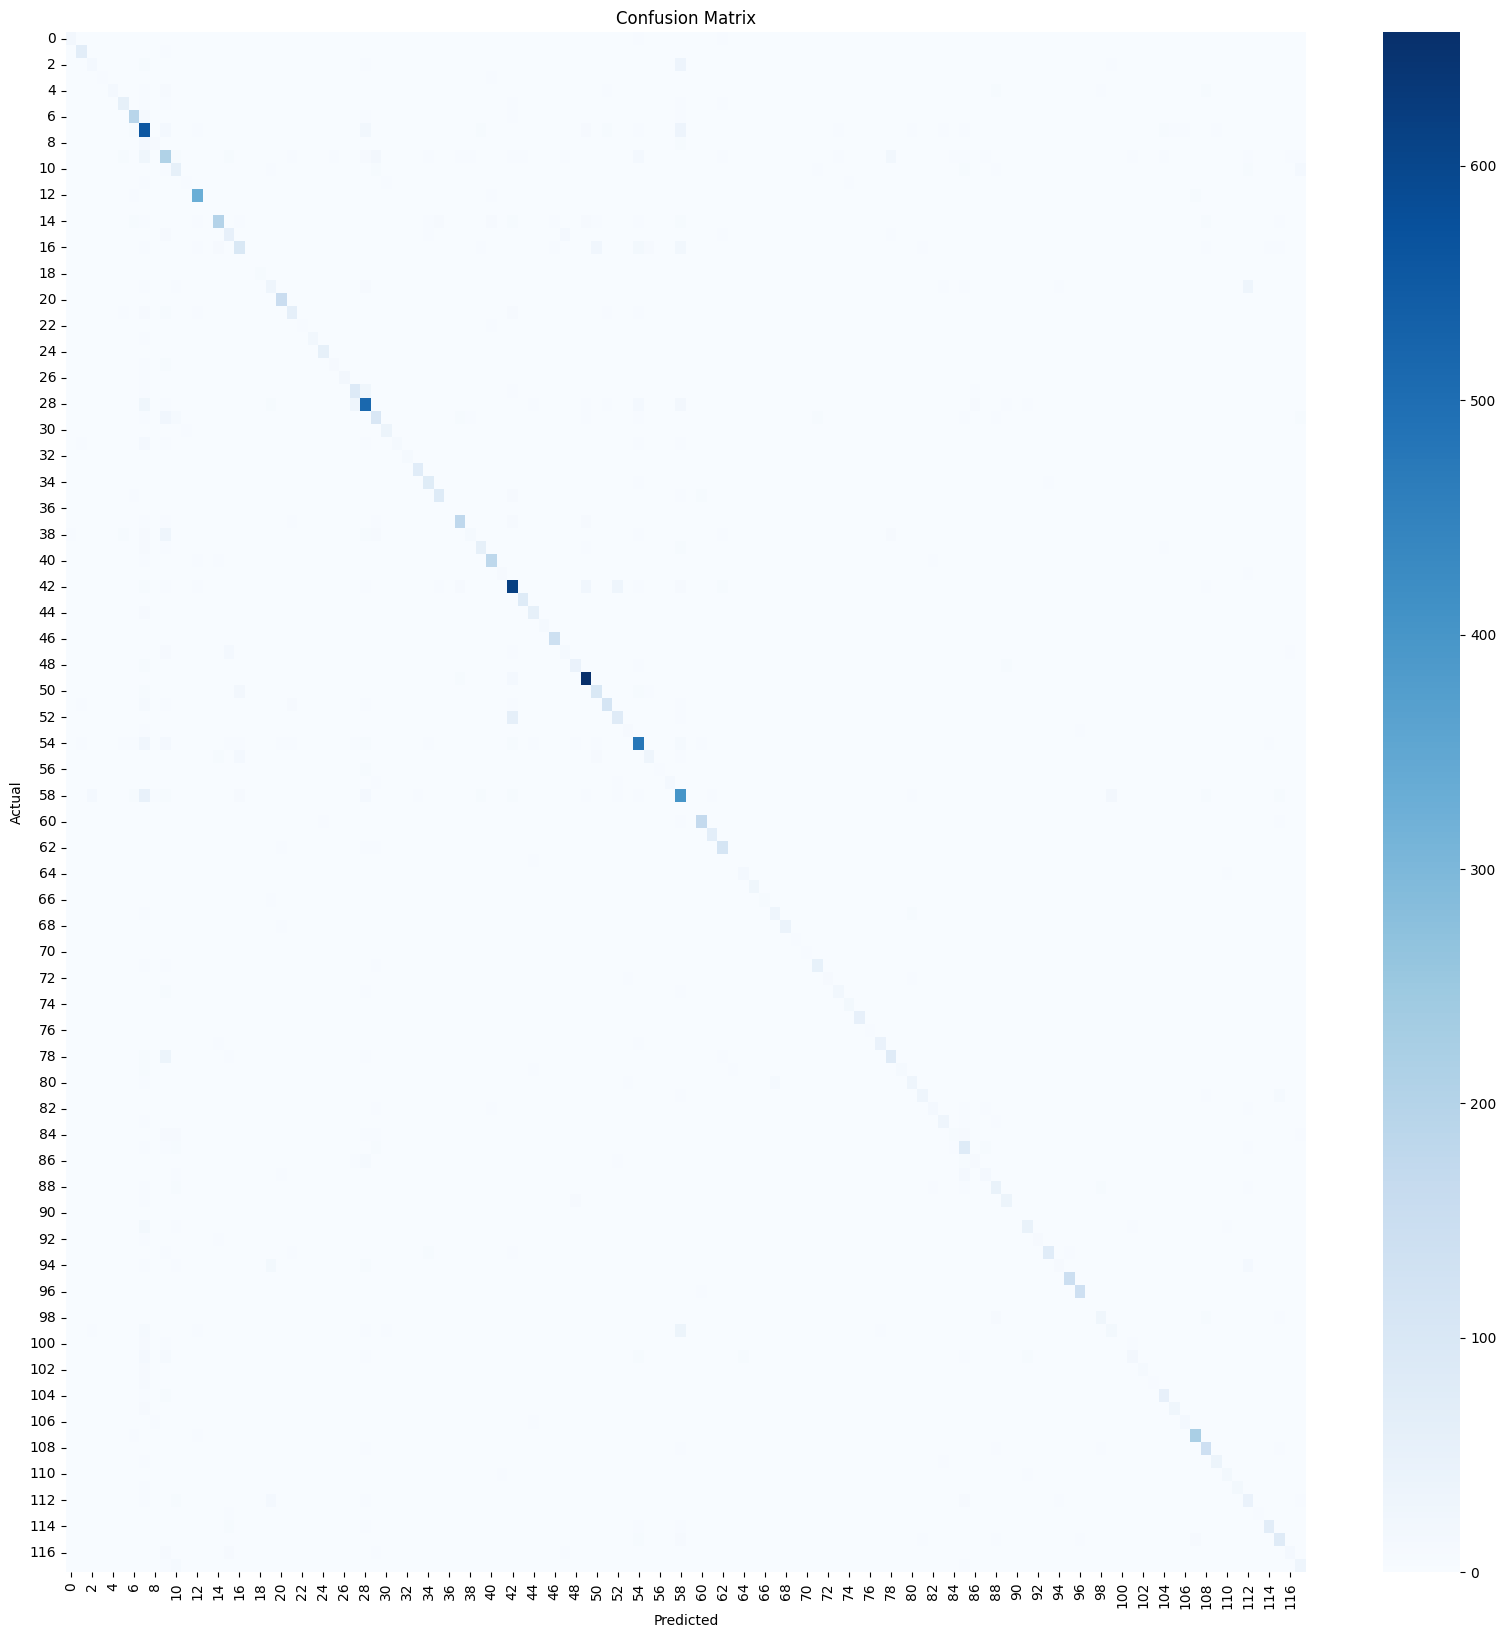

In [42]:
# ==================================================
# CONFUSION MATRIX
# ==================================================

cm = confusion_matrix(
    y_true,
    y_pred_classes
)

plt.figure(figsize=(20,20))

sns.heatmap(
    cm,
    cmap="Blues"
)

plt.title(
    "Confusion Matrix"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.show()

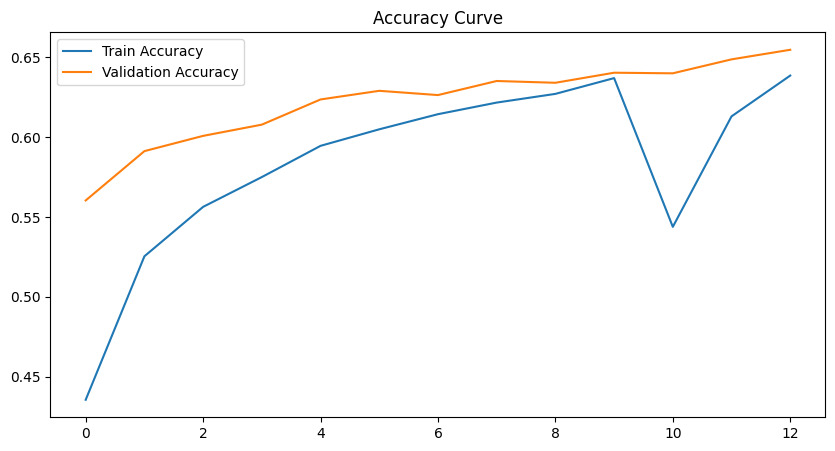

In [43]:
# ==================================================
# ACCURACY CURVE
# ==================================================

acc = (
    history.history["accuracy"]
    +
    history_fine.history["accuracy"]
)

val_acc = (
    history.history["val_accuracy"]
    +
    history_fine.history["val_accuracy"]
)

plt.figure(figsize=(10,5))

plt.plot(
    acc,
    label="Train Accuracy"
)

plt.plot(
    val_acc,
    label="Validation Accuracy"
)

plt.title(
    "Accuracy Curve"
)

plt.legend()

plt.show()

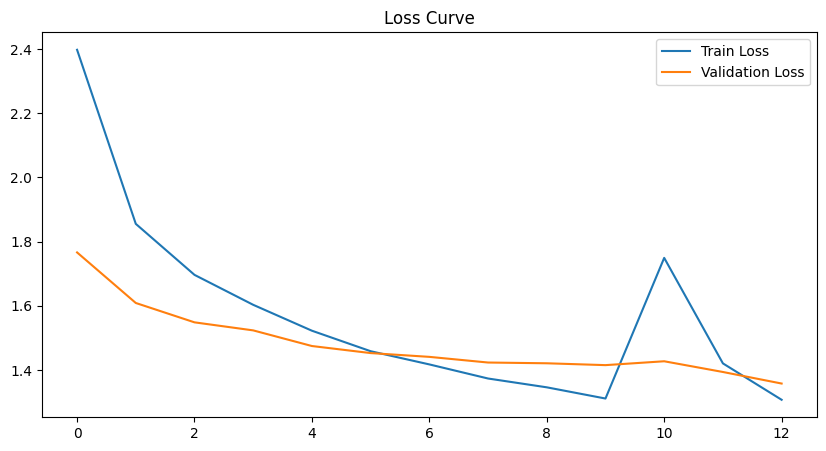

In [44]:
# ==================================================
# LOSS CURVE
# ==================================================

loss = (
    history.history["loss"]
    +
    history_fine.history["loss"]
)

val_loss = (
    history.history["val_loss"]
    +
    history_fine.history["val_loss"]
)

plt.figure(figsize=(10,5))

plt.plot(
    loss,
    label="Train Loss"
)

plt.plot(
    val_loss,
    label="Validation Loss"
)

plt.title(
    "Loss Curve"
)

plt.legend()

plt.show()

In [45]:
# ==================================================
# EXPORT MODEL
# ==================================================

model.save(
    "insect_classifier.h5"
)

print("="*50)
print("MODEL BERHASIL DISIMPAN")
print("="*50)

print(
    "File : insect_classifier.h5"
)

MODEL BERHASIL DISIMPAN
File : insect_classifier.h5


In [46]:
# ==================================================
# EXPORT LABEL
# ==================================================

with open(
    "class_names.json",
    "w"
) as f:

    json.dump(
        classes,
        f
    )

print(
    "class_names.json berhasil disimpan"
)

class_names.json berhasil disimpan
